<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_boundary_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D8_BOUNDARY_SPLIT — Topological Boundary Split

Status

Working prototype target.

Purpose

This notebook demonstrates how a soft radial morphogen field can be split into isolated topological address regions.

The previous experiment, D7_POSITION_GRADIENT, created spatial addresses using:

ring + petal

This experiment turns those soft addresses into separated regions with hard boundaries.

Core Idea

D7 answers:

where is the point?

D8 answers:

where does this region end?

A field address becomes a bounded cell.

Expected Result

The system should produce:

- radial morphogen field
- ring + petal address domains
- hard boundary map between domains
- table of detected topological regions

Diffusion Alphabet Mapping

Symbol:

D8_BOUNDARY_SPLIT

Family:

Geometry / Boundary / Segmentation

Meaning:

A diffusion-derived field is split into isolated address regions using winner-take-all competition between ring-petal domains.

Relation to D7

D7_POSITION_GRADIENT creates soft position:

D7_RING_MID + D7_PETAL_3

D8_BOUNDARY_SPLIT creates a bounded region:

D8_CELL_RING_MID_PETAL_3

Repository Name

notebooks/diffusion_boundary_split.ipynb

Experiment Label

Experiment 06 — Boundary Split / Topological Cell Map

Commit Message

Add diffusion boundary split prototype

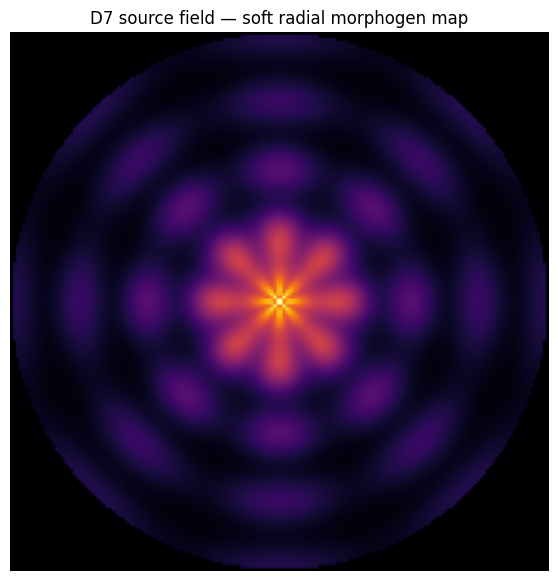

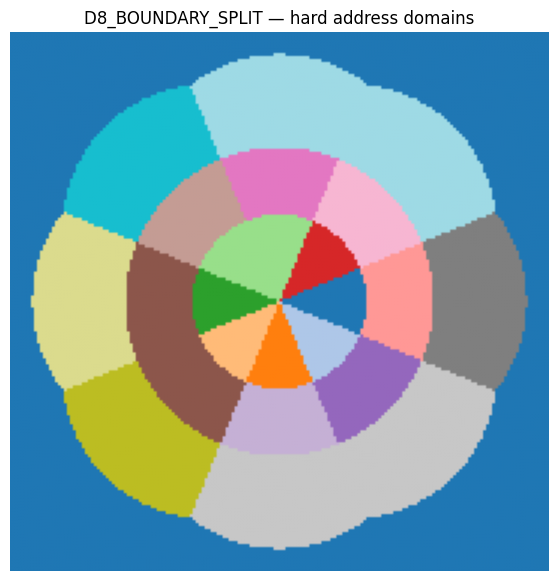

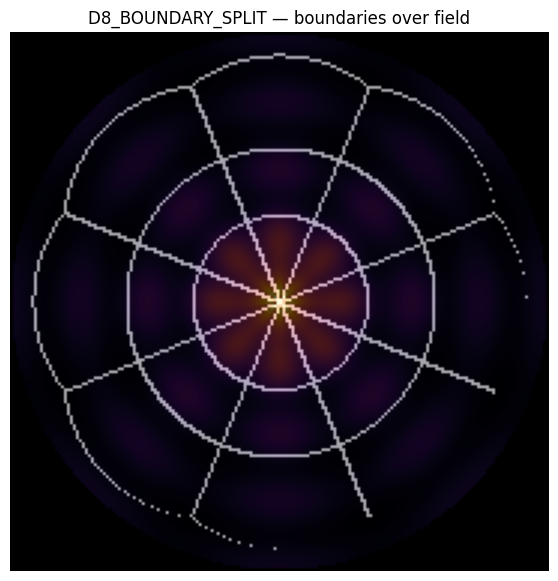

Detected domains: 24
Expected domains: 24


,STATE,LABEL,RING_INDEX,PETAL_INDEX,ADDRESS,AREA,MEAN_ACTIVATION,MAX_ACTIVATION
0,D8_BOUNDARY_SPLIT,0,0,0,D8_CELL_RING_INNER_PETAL_0,332,0.418,0.838
1,D8_BOUNDARY_SPLIT,1,0,1,D8_CELL_RING_INNER_PETAL_1,333,0.419,1.000
2,D8_BOUNDARY_SPLIT,2,0,2,D8_CELL_RING_INNER_PETAL_2,332,0.418,0.838
3,D8_BOUNDARY_SPLIT,3,0,3,D8_CELL_RING_INNER_PETAL_3,333,0.419,1.000
4,D8_BOUNDARY_SPLIT,4,0,4,D8_CELL_RING_INNER_PETAL_4,332,0.418,0.838
5,D8_BOUNDARY_SPLIT,5,0,5,D8_CELL_RING_INNER_PETAL_5,333,0.419,1.000
6,D8_BOUNDARY_SPLIT,6,0,6,D8_CELL_RING_INNER_PETAL_6,332,0.418,0.838
7,D8_BOUNDARY_SPLIT,7,0,7,D8_CELL_RING_INNER_PETAL_7,333,0.419,1.000
8,D8_BOUNDARY_SPLIT,8,1,0,D8_CELL_RING_MID_PETAL_0,704,0.139,0.250
9,D8_BOUNDARY_SPLIT,9,1,1,D8_CELL_RING_MID_PETAL_1,705,0.139,0.250


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def generate_radial_morphogen_field(size=180, petals=8, rings=4):
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)

    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)
    Theta = np.arctan2(Y, X)

    mask = (R <= 1.0).astype(float)

    center = np.exp(-18 * R**2)
    radial_wave = 0.5 + 0.5 * np.cos(2 * np.pi * rings * R)
    angular_wave = 0.5 + 0.5 * np.cos(petals * Theta)
    envelope = np.exp(-1.25 * R)

    Z = (
        0.55 * center
        + 0.45
        * envelope
        * (0.35 + 0.65 * radial_wave)
        * (0.35 + 0.65 * angular_wave)
    )

    Z = Z * mask
    Z = (Z - Z.min()) / (Z.max() - Z.min() + 1e-9)

    return Z, R, Theta, mask


def angular_distance(A, B):
    return np.abs(np.angle(np.exp(1j * (A - B))))


def build_boundary_split(
    Z,
    R,
    Theta,
    mask,
    petals=8,
    ring_centers=(0.20, 0.45, 0.70),
    sigma_r=0.10,
    sigma_theta=0.30,
):
    scores = []
    names = []

    for ring_index, ring_center in enumerate(ring_centers):
        for petal_index in range(petals):
            theta_center = 2 * np.pi * petal_index / petals

            dr = R - ring_center
            dt = angular_distance(Theta, theta_center)

            radial_score = np.exp(-(dr**2) / (2 * sigma_r**2))
            angular_score = np.exp(-(dt**2) / (2 * sigma_theta**2))

            score = radial_score * angular_score * (0.30 + 0.70 * Z) * mask

            scores.append(score)
            names.append((ring_index, petal_index))

    score_stack = np.stack(scores, axis=0)

    label_map = np.argmax(score_stack, axis=0)
    confidence = np.max(score_stack, axis=0)

    label_map = label_map.astype(int)
    label_map[mask == 0] = -1
    label_map[confidence < 0.03] = -1

    boundary = np.zeros_like(label_map, dtype=bool)

    boundary[:, 1:] |= label_map[:, 1:] != label_map[:, :-1]
    boundary[1:, :] |= label_map[1:, :] != label_map[:-1, :]

    boundary[label_map == -1] = False

    return label_map, boundary, confidence, names


def label_to_address(label, petals=8):
    if label < 0:
        return "D8_OUTSIDE"

    ring_index = label // petals
    petal_index = label % petals

    ring_names = {
        0: "RING_INNER",
        1: "RING_MID",
        2: "RING_OUTER",
    }

    ring_name = ring_names.get(ring_index, f"RING_{ring_index}")

    return f"D8_CELL_{ring_name}_PETAL_{petal_index}"


def summarize_domains(label_map, Z, petals=8):
    rows = []

    for label in sorted(np.unique(label_map)):
        if label < 0:
            continue

        region = label_map == label

        area = int(region.sum())
        mean_activation = float(Z[region].mean()) if area > 0 else 0.0
        max_activation = float(Z[region].max()) if area > 0 else 0.0

        ring_index = label // petals
        petal_index = label % petals

        rows.append(
            {
                "STATE": "D8_BOUNDARY_SPLIT",
                "LABEL": int(label),
                "RING_INDEX": int(ring_index),
                "PETAL_INDEX": int(petal_index),
                "ADDRESS": label_to_address(label, petals=petals),
                "AREA": area,
                "MEAN_ACTIVATION": round(mean_activation, 3),
                "MAX_ACTIVATION": round(max_activation, 3),
            }
        )

    return pd.DataFrame(rows)


def sample_boundary_addresses(label_map, Z, petals=8):
    h, w = Z.shape

    cx = (w - 1) / 2
    cy = (h - 1) / 2
    max_r = min(cx, cy)

    rows = []

    for r_norm in [0.20, 0.45, 0.70]:
        for petal_index in range(petals):
            theta = 2 * np.pi * petal_index / petals

            x = cx + np.cos(theta) * r_norm * max_r
            y = cy - np.sin(theta) * r_norm * max_r

            row = int(np.clip(round(y), 0, h - 1))
            col = int(np.clip(round(x), 0, w - 1))

            label = int(label_map[row, col])

            rows.append(
                {
                    "STATE": "D8_BOUNDARY_SPLIT",
                    "X": int(round(x)),
                    "Y": int(round(y)),
                    "R_NORM": round(float(r_norm), 2),
                    "PETAL_INDEX": petal_index,
                    "LABEL": label,
                    "ADDRESS": label_to_address(label, petals=petals),
                    "ACTIVATION": round(float(Z[row, col]), 3),
                    "POINT": f"R{r_norm:.2f}_P{petal_index}",
                }
            )

    return pd.DataFrame(rows)


petals = 8

Z, R, Theta, mask = generate_radial_morphogen_field(
    size=180,
    petals=petals,
    rings=4,
)

label_map, boundary, confidence, names = build_boundary_split(
    Z,
    R,
    Theta,
    mask,
    petals=petals,
)

df_domains = summarize_domains(label_map, Z, petals=petals)
df_samples = sample_boundary_addresses(label_map, Z, petals=petals)

plt.figure(figsize=(7, 7))
plt.imshow(Z, cmap="inferno")
plt.title("D7 source field — soft radial morphogen map")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(label_map, cmap="tab20")
plt.title("D8_BOUNDARY_SPLIT — hard address domains")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(Z, cmap="inferno")
plt.imshow(boundary, cmap="gray", alpha=0.65)
plt.title("D8_BOUNDARY_SPLIT — boundaries over field")
plt.axis("off")
plt.show()

print("Detected domains:", len(df_domains))
print("Expected domains:", 3 * petals)

df_domains

In [2]:
df_samples

,STATE,X,Y,R_NORM,PETAL_INDEX,LABEL,ADDRESS,ACTIVATION,POINT
0,D8_BOUNDARY_SPLIT,107,90,0.20,0,0,D8_CELL_RING_INNER_PETAL_0,0.539,R0.20_P0
1,D8_BOUNDARY_SPLIT,102,77,0.20,1,7,D8_CELL_RING_INNER_PETAL_7,0.543,R0.20_P1
2,D8_BOUNDARY_SPLIT,90,72,0.20,2,6,D8_CELL_RING_INNER_PETAL_6,0.539,R0.20_P2
3,D8_BOUNDARY_SPLIT,77,77,0.20,3,5,D8_CELL_RING_INNER_PETAL_5,0.543,R0.20_P3
4,D8_BOUNDARY_SPLIT,72,90,0.20,4,4,D8_CELL_RING_INNER_PETAL_4,0.539,R0.20_P4
5,D8_BOUNDARY_SPLIT,77,102,0.20,5,3,D8_CELL_RING_INNER_PETAL_3,0.543,R0.20_P5
6,D8_BOUNDARY_SPLIT,90,107,0.20,6,2,D8_CELL_RING_INNER_PETAL_2,0.539,R0.20_P6
7,D8_BOUNDARY_SPLIT,102,102,0.20,7,1,D8_CELL_RING_INNER_PETAL_1,0.543,R0.20_P7
8,D8_BOUNDARY_SPLIT,130,90,0.45,0,8,D8_CELL_RING_MID_PETAL_0,0.218,R0.45_P0
9,D8_BOUNDARY_SPLIT,118,61,0.45,1,15,D8_CELL_RING_MID_PETAL_7,0.215,R0.45_P1
